In [3]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

smoothed = True

In [4]:
df = pd.read_csv(f'/Users/mrenke/data/ds-stressrisk/interim_sum_data/encoding_params_smoothed-{smoothed}.csv')
df['mu_norm'] = np.round(np.exp(df['mu']))

In [5]:
#bins = np.logspace(0,10,num=5, base=2.718)
#pars['mu_bin'] = pd.cut(pars['mu'], bins)

bins = np.concatenate([np.arange(0, 20, 5), np.arange(20, 50, 10), np.arange(50, 100, 20)]) # np.arange(0, 100, 5) #bins = np.arange(0, 25, 5)
df['mu_bin'] = pd.cut(df['mu_norm'], bins, labels=False) # labels=False implies you just want the bins back.

mean_pars = df.groupby(['subject', 'session','mu_bin']).mean().set_index('group', append=True)


In [16]:
pars

,subject,session,voxel_n,mu,sd,amplitude,baseline,group,mu_norm,mu_bin
0,1,1,23,2.596122,0.410144,0.256250,-0.097944,0,13.0,2.0
1,1,1,24,3.313220,0.291669,0.412319,-0.220319,0,27.0,4.0
2,1,1,43,2.621415,0.358445,0.388330,-0.646244,0,14.0,2.0
3,1,1,44,2.611045,0.283278,0.410252,-0.559882,0,14.0,2.0
4,1,1,68,2.634493,0.440751,0.440440,-0.391139,0,14.0,2.0
...,...,...,...,...,...,...,...,...,...,...
5389,61,2,979,1.829940,0.103231,0.366824,0.160295,0,6.0,1.0
5390,61,2,981,2.980996,0.279415,0.407409,-0.181989,0,20.0,3.0
5391,61,2,1006,2.869620,0.215606,0.332438,-0.182689,0,18.0,3.0
5392,61,2,1019,3.119550,0.123091,0.372040,-0.040610,0,23.0,4.0


Text(0.5, 1.0, 'group 1')

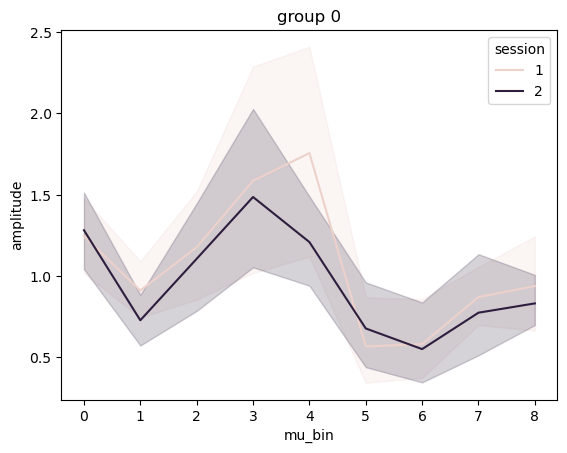

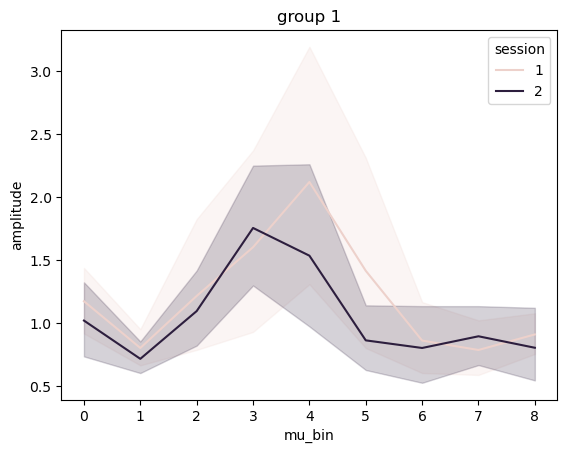

In [6]:
sns.lineplot(data=mean_pars.xs(0,0,'group').reset_index(), x='mu_bin', y='amplitude', hue='session') #, col='group') # mu_bin does not work as x !
plt.title('group 0')
plt.figure()
sns.lineplot(data=mean_pars.xs(1,0,'group').reset_index(), x='mu_bin', y='amplitude', hue='session') #, col='group') # mu_bin does not work as x !
plt.title('group 1')


Text(0.5, 1.0, 'session 2')

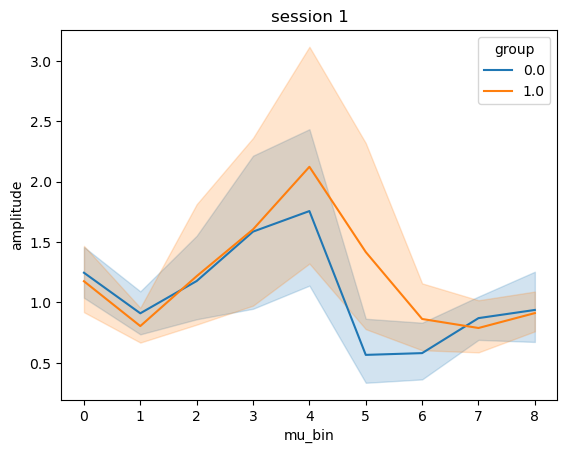

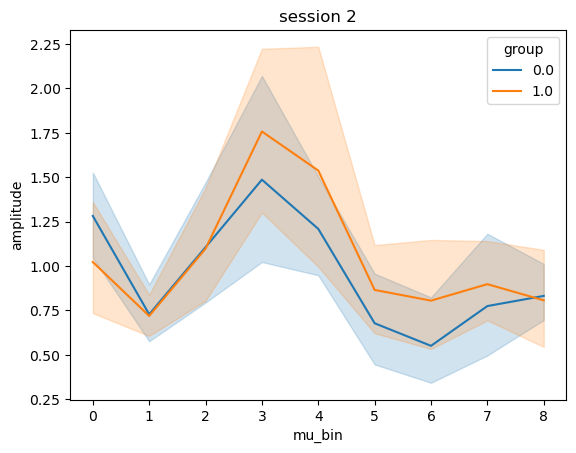

In [7]:
sns.lineplot(data=mean_pars.xs(1,0,'session').reset_index(), x='mu_bin', y='amplitude', hue='group') #, col='group') # mu_bin does not work as x !
plt.title('session 1')
plt.figure()
sns.lineplot(data=mean_pars.xs(2,0,'session').reset_index(), x='mu_bin', y='amplitude', hue='group') #, col='group') # mu_bin does not work as x !
plt.title('session 2')


In [8]:
num_knots = 7
knots = np.quantile(df['mu_norm'], np.linspace(0, 1, num_knots))

In [9]:
def plot_scatter(data, figsize=(10, 6)):
    _, ax = plt.subplots(figsize=figsize)
    ax.scatter(data["mu_norm"], data["amplitude"], alpha=0.4, s=30)
    plt.xlim(0,100)
    return ax

In [10]:
def plot_knots(knots, ax):
    for knot in knots:
        ax.axvline(knot, color="0.1", alpha=0.4)
    return ax

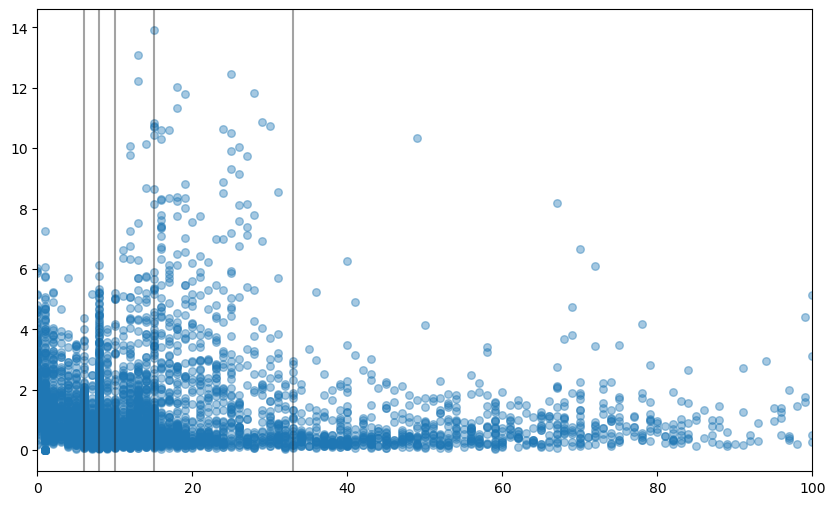

In [11]:
ax = plot_scatter(df)
plot_knots(knots, ax);

In [20]:
import bambi as bmb

iknots = knots[1:-1]

# Define dictionary of priors
priors = {
    "Intercept": bmb.Prior("Normal", mu=100, sigma=10),
    "common": bmb.Prior("Normal", mu=0, sigma=10),
    "sigma": bmb.Prior("Exponential", lam=1)
}

# Define model
# The intercept=True means the basis also spans the intercept, as originally done in the book example.
model = bmb.Model("amplitude ~ bs(mu_norm*session*group, knots=iknots, intercept=True)", df, priors=priors)

model

Formula: amplitude ~ bs(mu_norm*session*group, knots=iknots, intercept=True)
Family name: Gaussian
Link: identity
Observations: 5394
Priors:
  Common-level effects
    Intercept ~ Normal(mu: 100, sigma: 10)
    bs(mu_norm * session * group, knots = iknots, intercept = True) ~ Normal(mu: 0, sigma: 10)

  Auxiliary parameters
    sigma ~ Exponential(lam: 1)

In [12]:
import bambi as bmb
df = pars
reg = 'mu_bin'
model = bmb.Model(f'amplitude ~ bs({reg}, df=7)*C(session)*C(group)+(bs({reg}, df=7)*C(session)|subject)', data=df.reset_index)
idata = model.fit()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, bs(mu_norm, df = 7), C(session), bs(mu_norm, df = 7):C(session), C(group), bs(mu_norm, df = 7):C(group), C(session):C(group), bs(mu_norm, df = 7):C(session):C(group), 1|subject_sigma, 1|subject_offset, bs(mu_norm, df = 7)|subject_sigma, bs(mu_norm, df = 7)|subject_offset, C(session)|subject_sigma, C(session)|subject_offset, bs(mu_norm, df = 7):C(session)|subject_sigma, bs(mu_norm, df = 7):C(session)|subject_offset, amplitude_sigma]


Sampling 4 chains for 1_000 tune and 559 draw iterations (4_000 + 2_236 draws total) took 5165 seconds.


In [15]:
idata.to_netcdf('/Volumes/mrenkeED/data/ds-stressrisk/derivatives/hierachical_models/encoding_params_amplitude-mu_spline-regression_mu-norm_stopped.netcdf')

'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/hierachical_models/encoding_params_amplitude-mu_spline-regression_mu-norm_stopped.netcdf'

In [22]:
SEED = 7355608

idata = model.fit(random_seed=SEED, idata_kwargs={"log_likelihood": True})
idata.to_netcdf('/Volumes/mrenkeED/data/ds-stressrisk/derivatives/hierachical_models/encoding_params_amplitude-mu_spline-regression.netcdf')

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, bs(mu_norm * session * group, knots = iknots, intercept = True), amplitude_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1026 seconds.


In [41]:
import arviz as az

traces = az.from_netcdf('/Volumes/mrenkeED/data/ds-stressrisk/derivatives/hierachical_models/encoding_params_amplitude-mu_spline-regression.netcdf')

In [8]:
#traces.posterior['bs(mu_norm * session * group, knots = iknots, intercept = True)']
posterior_stacked = az.extract(traces)


In [9]:
posterior_stacked

<xarray.Dataset>
Dimensions:                                                              (
                                                                          sample: 4000,
                                                                          bs(mu_norm * session * group, knots = iknots, intercept = True)_dim: 17)
Coordinates:
  * bs(mu_norm * session * group, knots = iknots, intercept = True)_dim  (bs(mu_norm * session * group, knots = iknots, intercept = True)_dim) int64 ...
  * sample                                                               (sample) object MultiIndex
  * chain                                                                (sample) int64 ...
  * draw                                                                 (sample) int64 ...
Data variables:
    Intercept                                                            (sample) float64 ...
    bs(mu_norm * session * group, knots = iknots, intercept = True)      (bs(mu_norm * session * group, knots = iknots, intercept = True)_dim, sample) float64 ...
    amplitude_sigma                                                      (sample) float64 ...
Attributes:
    created_at:                  2023-08-02T14:58:13.914782
    arviz_version:               0.14.0
    inference_library:           pymc
    inference_library_version:   4.3.0
    sampling_time:               1025.841076850891
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.9.2

In [38]:
az.summary(traces, var_names=["Intercept", "bs(mu_norm * session * group, knots = iknots, intercept = True)", "amplitude_sigma"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,1.513,2.494,-2.621,6.872,0.112,0.081,495.0,585.0,1.01
"bs(mu_norm * session * group, knots = iknots, intercept = True)[0]",-0.250,2.494,-5.596,3.898,0.113,0.080,494.0,585.0,1.01
"bs(mu_norm * session * group, knots = iknots, intercept = True)[1]",0.436,2.557,-4.752,4.915,0.113,0.080,516.0,622.0,1.01
"bs(mu_norm * session * group, knots = iknots, intercept = True)[2]",-1.420,2.548,-6.630,2.972,0.112,0.079,515.0,633.0,1.01
"bs(mu_norm * session * group, knots = iknots, intercept = True)[3]",0.434,2.546,-4.724,4.967,0.113,0.080,512.0,652.0,1.01
"bs(mu_norm * session * group, knots = iknots, intercept = True)[4]",-0.730,2.510,-5.832,3.705,0.113,0.080,496.0,594.0,1.01
"bs(mu_norm * session * group, knots = iknots, intercept = True)[5]",-1.062,2.525,-6.047,3.499,0.112,0.081,506.0,605.0,1.01
"bs(mu_norm * session * group, knots = iknots, intercept = True)[6]",-0.401,2.502,-5.705,3.845,0.113,0.080,494.0,602.0,1.01
"bs(mu_norm * session * group, knots = iknots, intercept = True)[7]",-0.944,2.505,-6.147,3.364,0.112,0.081,502.0,579.0,1.01
"bs(mu_norm * session * group, knots = iknots, intercept = True)[8]",-0.613,2.506,-5.717,3.815,0.113,0.080,493.0,592.0,1.01


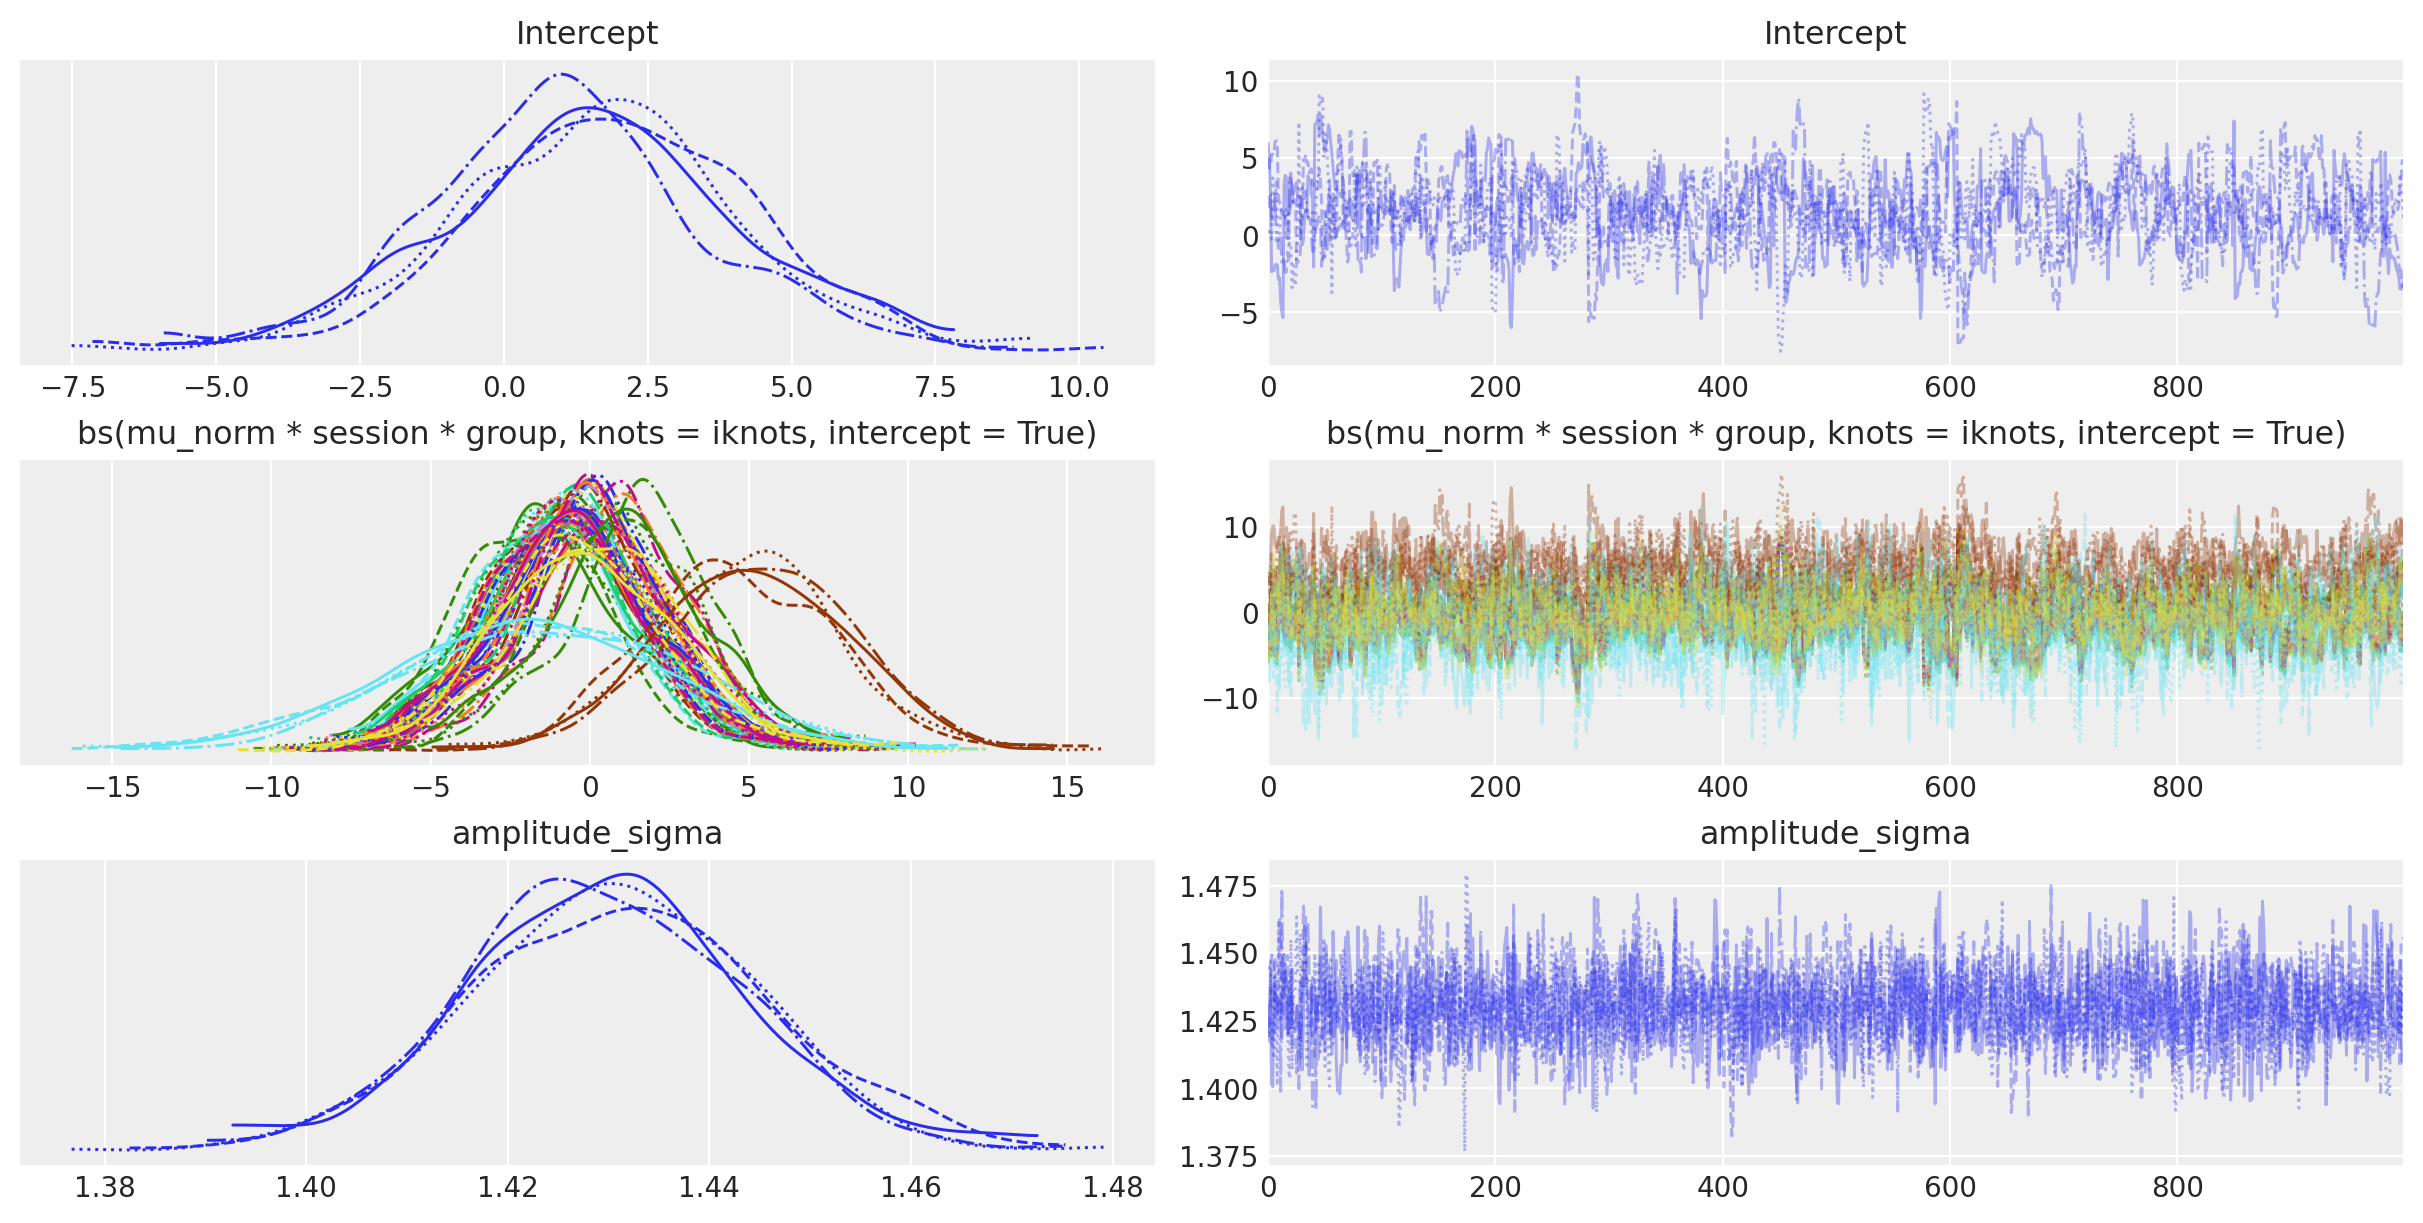

In [33]:
az.plot_trace(traces, var_names=["Intercept", "bs(mu_norm * session * group, knots = iknots, intercept = True)", "amplitude_sigma"]);



In [36]:
bids_folder= '/Users/mrenke/data/ds-stressrisk'
model_label= 1
idata = az.from_netcdf(op.join(bids_folder, f'derivatives/cogmodels/model-{model_label}_trace.netcdf'))


In [37]:
idata.posterior

<xarray.Dataset>
Dimensions:                     (chain: 4, draw: 1000,
                                 n1_evidence_sd_regressors: 4, subject: 50,
                                 n2_evidence_sd_regressors: 4,
                                 risky_prior_mu_regressors: 4,
                                 risky_prior_std_regressors: 4,
                                 safe_prior_mu_regressors: 4,
                                 safe_prior_std_regressors: 4, p_dim_0: 11891)
Coordinates:
  * chain                       (chain) int64 0 1 2 3
  * draw                        (draw) int64 0 1 2 3 4 5 ... 995 996 997 998 999
  * n1_evidence_sd_regressors   (n1_evidence_sd_regressors) object 'Intercept...
  * subject                     (subject) int64 1 2 3 4 5 9 ... 55 57 58 59 61
  * n2_evidence_sd_regressors   (n2_evidence_sd_regressors) object 'Intercept...
  * risky_prior_mu_regressors   (risky_prior_mu_regressors) object 'Intercept...
  * risky_prior_std_regressors  (risky_prior_std_regressors) object 'Intercep...
  * safe_prior_mu_regressors    (safe_prior_mu_regressors) object 'Intercept'...
  * safe_prior_std_regressors   (safe_prior_std_regressors) object 'Intercept...
  * p_dim_0                     (p_dim_0) int64 0 1 2 3 ... 11888 11889 11890
Data variables: (12/25)
    n1_evidence_sd_mu           (chain, draw, n1_evidence_sd_regressors) float64 ...
    n1_evidence_sd_offset       (chain, draw, subject, n1_evidence_sd_regressors) float64 ...
    n2_evidence_sd_mu           (chain, draw, n2_evidence_sd_regressors) float64 ...
    n2_evidence_sd_offset       (chain, draw, subject, n2_evidence_sd_regressors) float64 ...
    risky_prior_mu_mu           (chain, draw, risky_prior_mu_regressors) float64 ...
    risky_prior_mu_offset       (chain, draw, subject, risky_prior_mu_regressors) float64 ...
    ...                          ...
    n2_evidence_sd              (chain, draw, subject, n2_evidence_sd_regressors) float64 ...
    risky_prior_mu              (chain, draw, subject, risky_prior_mu_regressors) float64 ...
    risky_prior_std             (chain, draw, subject, risky_prior_std_regressors) float64 ...
    safe_prior_mu               (chain, draw, subject, safe_prior_mu_regressors) float64 ...
    safe_prior_std              (chain, draw, subject, safe_prior_std_regressors) float64 ...
    p                           (chain, draw, p_dim_0) float64 ...
Attributes:
    created_at:                 2023-06-23T13:29:54.813248
    arviz_version:              0.14.0
    inference_library:          pymc
    inference_library_version:  4.3.0
    sampling_time:              3008.8333070278168
    tuning_steps:               1000